In [ ]:
import os

os.listdir()

['.config', '.ipynb_checkpoints', 'Fake.csv', 'True.csv', 'sample_data']

In [ ]:
import pandas as pd

fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

print("Fake news:", fake.shape)
print("Real news:", true.shape)

Fake news: (23481, 4)
Real news: (21417, 4)


In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
df = pd.concat([fake, true], ignore_index=True)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df["content"] = df["title"] + " " + df["text"]

In [ ]:
df[["content", "label"]].head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [ ]:
import re

def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df["clean_content"] = df["content"].apply(clean_text)

In [ ]:
print("Original:")
print(df["content"].iloc[0])

print("\nCleaned:")
print(df["clean_content"].iloc[0])

Original:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Exec

Check the cleaned data

In [ ]:
df[["content", "clean_content", "label"]].head()

,content,clean_content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out th circuit court committed...,0
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects us to lift jones act shipp...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump just accidentally confirmed he leak...,0
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads for scotland to reopen a go...,1


In [ ]:
print(df["clean_content"].isnull().sum())
print((df["clean_content"] == "").sum())

0
9


In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 35918
Testing data: 8980


Convert text into numbers using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (35918, 5000)
Testing shape: (8980, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1 1 0 1 0]


0 = FAKE ❌
1 = REAL ✅

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9896436525612472
Accuracy percentage: 98.96436525612472 %


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["FAKE", "REAL"]
))

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Confusion Matrix

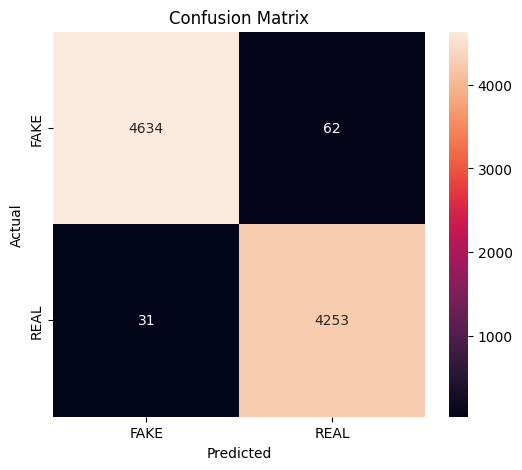

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

compare 3 ML models

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.9398663697104677


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9957683741648107


In [ ]:
models = {
    "Logistic Regression": y_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred
}

for name, predictions in models.items():
    acc = accuracy_score(y_test, predictions)
    print(f"{name}: {acc * 100:.2f}%")

Logistic Regression: 98.96%
Naive Bayes: 93.99%
SVM: 99.58%


Test your model with YOUR OWN news

In [ ]:
def predict_news(news):
    cleaned = clean_text(news)
    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "FAKE NEWS ❌"
    else:
        return "REAL NEWS ✅"

In [ ]:
news = """
The Indian government announced a new education policy
to improve digital learning facilities in schools.
"""

print(predict_news(news))

FAKE NEWS ❌


Add confidence score

In [ ]:
def predict_news_with_confidence(news):
    cleaned = clean_text(news)
    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]
    probabilities = model.predict_proba(vector)[0]

    confidence = max(probabilities) * 100

    if prediction == 0:
        result = "FAKE NEWS ❌"
    else:
        result = "REAL NEWS ✅"

    return result, confidence

In [ ]:
news = """
The government announced a new policy to improve
education facilities across the country.
"""

result, confidence = predict_news_with_confidence(news)

print("Prediction:", result)
print(f"Confidence: {confidence:.2f}%")

Prediction: FAKE NEWS ❌
Confidence: 64.35%


In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "SVM": accuracy_score(y_test, svm_pred)
}

for model_name, score in results.items():
    print(f"{model_name}: {score*100:.2f}%")

Logistic Regression: 98.96%
Naive Bayes: 93.99%
SVM: 99.58%


In [ ]:
import pickle

with open("fake_news_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
